Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [1]:
from pathlib import Path
import sys, importlib
import os

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_fast"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)


Project root directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package
Experiment directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
RAW data directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[CAPTION] Histogram of v1 before and after cleaning.
[CAPTION] Histogram of v2 before and after cleaning.
[CAPTION] Histogram of v3 before and after cleaning.
[CAPTION] Histogram of v4 before and after cleaning.
[CAPTION] Histogram of v5 before and after cleaning.
[CAPTION] Histogram of v6 before and after cleaning.
[CAPTION] Histogram of v7 before and after cleaning.
[CAPTION] Histogram of v8 before and after cleaning.
[CAPTION] Histogram of v9 before and after cleaning.
[CAPTION] Histogram of v10 before and after cleaning.
[CAPTION] Histogram of v11 before and after cleaning.
[CAPTION] Histogram of v12 before and after cleaning.
[CAPTION] Histogram of v13 before and after cleaning.
[CAPTION] Histogram of v14 before and after cleaning.
[CAPTION] Histogram of v15 before and after cleaning.
[CAPTION] Histogram of v16 before and after cleaning.
[CAPTION] Histogram of v17 before and after cleaning.


KeyboardInterrupt: 

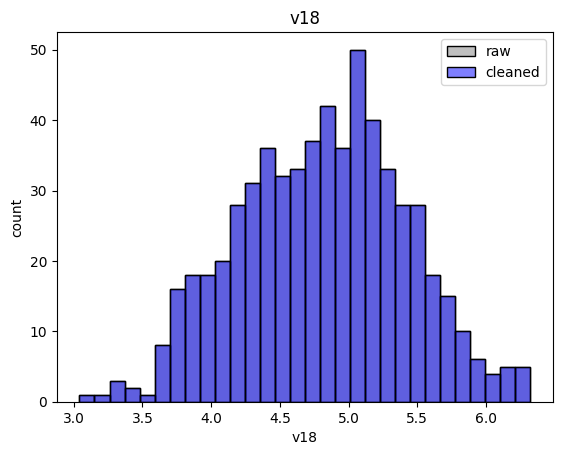

In [2]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper

DataImportWrapper().clean_all()

Overview generation of Datasets in experiment

In [ ]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.csv', reuse_csv=True)
overview_df

Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


In [ ]:

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from IPython.display import Image, display
import pandas as pd
SplitWrapper().split_all(reuse_splits=True)
run_summary(cfg.SPLITS_DIR, EXP_DIR/'split_summary.csv', EXP_DIR/'split_fig')
display(Image(filename=EXP_DIR/'split_fig/summary_all.png'))
display(Image(filename=EXP_DIR/'split_fig/lutra_lutra_summary.png'))
display(Image(filename=EXP_DIR/'split_fig/split_proportions.png'))



Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [ ]:
from FIT_python.Visualisations.plot_style import map_sex
from FIT_python import config as cfg

from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    select_top_features,
    plot_sex_boxplots,
    plot_individual_boxplots,
)
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# Pfad zur Datei
#file_path = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\cleaned\Eurasian_Otter.parquet")
file_path = cfg.CLEANED_DIR / "Eurasian_Otter.parquet"


# Unterordner für Data Exploration anlegen
exp_dir_dataexpl = EXP_DIR / "data_exploration_figures"
exp_dir_dataexpl.mkdir(parents=True, exist_ok=True)

# Laden des DataFrames
otter_df = pd.read_parquet(file_path)

otter_df = otter_df.dropna(subset=['sex', 'individual_id'])
otter_df = otter_df[~otter_df['sex'].astype(str).str.lower().eq('na')]
otter_df = otter_df[~otter_df['individual_id'].astype(str).str.lower().eq('na')]
otter_df['sex_mapped'] = map_sex(otter_df['sex'])

top_sex = select_top_features(otter_df, 'sex', k=4)
top_ind = select_top_features(otter_df, 'individual_id', k=4)


plot_feature_correlation_matrix(otter_df, exp_dir_dataexpl)
plot_sex_boxplots(otter_df, top_sex, exp_dir_dataexpl, 'sex_boxplots.png')
plot_individual_boxplots(otter_df, top_ind, exp_dir_dataexpl, 'individual_boxplots.png')



Visualisierung mit Umap alle Otter

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)

plt.tight_layout()

# Speichern
fig_path = Path(exp_dir_dataexpl) / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


Training sex Model

In [ ]:
# ────────────────────────────────────────────────────────────────
# Sex Classification: Model Training with Bayesian Optimisation
# ────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier  # Optional, falls CatBoost aktiv
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# deine vorhandenen Helper
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric

# ─── Models Definition ───────────────────────────────────────────
# ─── Models Definition (LDA, Logistic Regression, XGBoost Variants) ──────────
MODELS = {
    # Logistic Regression Variants
    "logreg_l2": LogisticRegression(
        penalty="l2", solver="lbfgs", C=1.0, max_iter=500
    ),
    "logreg_l1": LogisticRegression(
        penalty="l1", solver="saga", C=1.0, max_iter=500
    ),

    # LDA Baseline
    "lda": LinearDiscriminantAnalysis(),

    # XGBoost Variants
    "xgb_std": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_deep": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=10,
        subsample=0.9, colsample_bytree=0.9,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_fast": XGBClassifier(
        n_estimators=50, learning_rate=0.2, max_depth=4,
        subsample=0.8, colsample_bytree=0.7,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_reg": XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.85, colsample_bytree=0.85,
        use_label_encoder=False, verbosity=0
    ),
}
# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex()       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(cfg.RESULTS_DATA_DIR)

Best Models Ballaned accuracy , majority individual  classification , accuracy , und mean log loss For otter

inference for inference sets for 4 models balanced acc ; maj test; beg loss ; accuracy

Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
Base data dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data
Benchmark dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\benchmark
✅ Benchmark-Tabelle gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\benchmark\benchmark_summary_best_test.csv


,Species,Balanced Accuracy (Test),Accuracy (Test),Majority Vote Individual Accuracy (Test),Female Accuracy (Test),Male Accuracy (Test),Accuracy (CV),Balanced Accuracy (CV),Log Loss (CV)
1,Amur Tiger,0.962,0.970,1.000,1.000,0.921,0.886,0.888,-0.450
2,Bengal Tiger,0.945,0.944,0.857,0.933,0.850,0.723,0.705,-1.659
0,Mountain Lion,0.821,0.848,0.857,0.958,0.681,0.874,0.860,-0.512
2,Eurasian Otter,0.807,0.808,1.000,0.812,0.806,0.798,0.758,-0.837
0,Giant Panda,0.788,0.789,0.778,0.858,0.564,0.669,0.731,-0.987
0,Lowlandtapir,0.542,0.542,0.625,0.665,0.445,0.487,0.489,-1.364
2,Cheetah,0.481,0.463,0.500,0.641,0.430,0.479,0.529,-0.833
0,White Rhino,0.459,0.470,0.444,0.484,0.502,0.466,0.475,-1.677


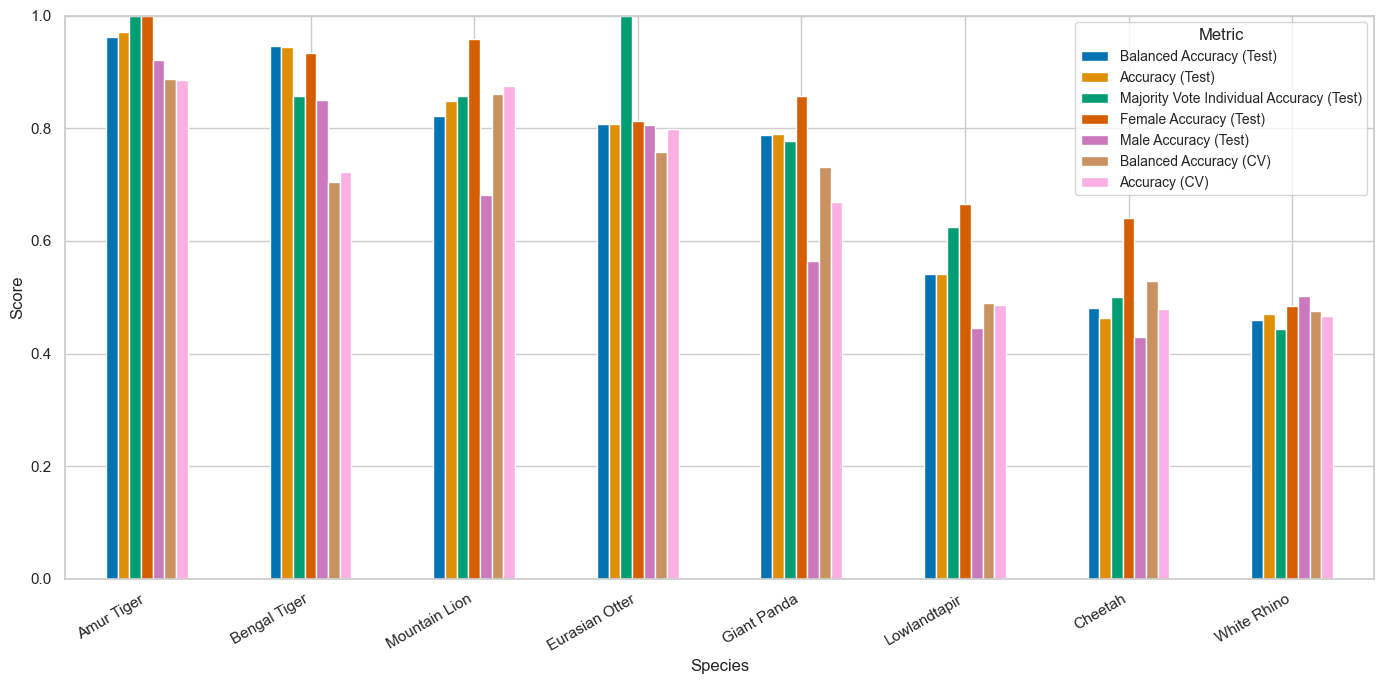

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, sys, importlib

# ---------------------------------------------------------------------
# Projekt-Setup über config
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# Basis- und Ergebnis-Verzeichnisse aus config
base_dir = config.RESULTS_DATA_DIR
benchmark_dir = config.EXPERIMENT_ROOT / "benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", config.EXPERIMENT_ROOT)
print("Base data dir:", base_dir)
print("Benchmark dir:", benchmark_dir)

benchmark_rows = []

# Sammeln der besten Modelle pro Spezies (beste Test Balanced Accuracy)
for species_dir in base_dir.glob("*"):
    best_csv = species_dir / "best_models.csv"
    all_csv = species_dir / "all_results.csv"

    if best_csv.exists() and all_csv.exists():
        df_best = pd.read_csv(best_csv)
        df_all = pd.read_csv(all_csv)

        if "balanced_test_acc" not in df_all.columns:
            print(f"⚠️ Keine Balanced Accuracy (Test) für {species_dir.name}, überspringe.")
            continue

        # Modell mit bester Test-Balanced-Accuracy auswählen
        best_row = df_all.sort_values("balanced_test_acc", ascending=False).iloc[0]
        benchmark_rows.append(best_row)

benchmark_df = pd.DataFrame(benchmark_rows)

# Spalten sauber benennen (Test und CV getrennt)
col_map = {
    "species": "Species",
    # Test-Metriken
    "balanced_test_acc": "Balanced Accuracy (Test)",
    "accuracy_test": "Accuracy (Test)",
    "maj_test_pct": "Majority Vote Individual Accuracy (Test)",
    "female_test_acc": "Female Accuracy (Test)",
    "male_test_acc": "Male Accuracy (Test)",
    # CV-Metriken
    "mean_test_accuracy": "Accuracy (CV)",
    "mean_test_balanced_accuracy": "Balanced Accuracy (CV)",
    "mean_test_neg_log_loss": "Log Loss (CV)",
}

cols_to_keep = [c for c in col_map.keys() if c in benchmark_df.columns]
benchmark_df = benchmark_df[cols_to_keep]
benchmark_df = benchmark_df.rename(columns=col_map)

# Species-Namen säubern
benchmark_df["Species"] = (
    benchmark_df["Species"]
    .str.replace("_", " ")
    .str.title()
)

# Runden und sortieren nach Balanced Accuracy (Test)
benchmark_df = benchmark_df.round(3)
benchmark_df = benchmark_df.sort_values(by="Balanced Accuracy (Test)", ascending=False)

# Speichern
out_path = benchmark_dir / "benchmark_summary_best_test.csv"
benchmark_df.to_csv(out_path, index=False)
print(f"✅ Benchmark-Tabelle gespeichert unter: {out_path}")
display(benchmark_df)

# Plot mit sns Farbpalette
sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", n_colors=len(benchmark_df.columns) - 1)

# Plotten aller CV- und Testmetriken (ohne Log Loss)
metrics_for_plot = [
    "Balanced Accuracy (Test)",
    "Accuracy (Test)",
    "Majority Vote Individual Accuracy (Test)",
    "Female Accuracy (Test)",
    "Male Accuracy (Test)",
    "Balanced Accuracy (CV)",
    "Accuracy (CV)",
]

ax = benchmark_df.set_index("Species")[metrics_for_plot].plot(
    kind="bar", figsize=(14, 7), color=palette
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=300)
plt.show()


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.373e-02, tolerance: 4.343e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.616e-02, tolerance: 4.343e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

Verteilung nach Splits:
__split__
train        380
test         167
inference     81
Name: count, dtype: int64 



,id,species,individual_id,date,location,dataorigin,substrate,sex,trail,dist1_2,...,t12_13_15,t13_14_15,t13_14_17,t12_15_17,t13_14_16,Fold,__split__,pred_sex,pred_proba_f,pred_proba_m
0,1989,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.195434,...,45.614587,45.614587,22.519170,21.979226,16.757686,3.0,train,m,0.06,0.94
1,1990,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.078705,...,43.571373,43.571373,18.882423,19.962604,12.480125,3.0,train,m,0.36,0.64
2,1991,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.130907,...,40.660357,40.660357,19.281442,18.500245,13.776469,3.0,train,f,0.50,0.50
3,1992,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.211265,...,39.990505,39.990505,15.972883,15.033439,10.469460,3.0,train,m,0.24,0.76
4,1993,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,1.938635,...,46.219886,46.219886,22.458678,21.324311,16.092507,3.0,train,m,0.00,1.00


C:\Users\Frede\AppData\Local\Temp\ipykernel_28264\3189166676.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


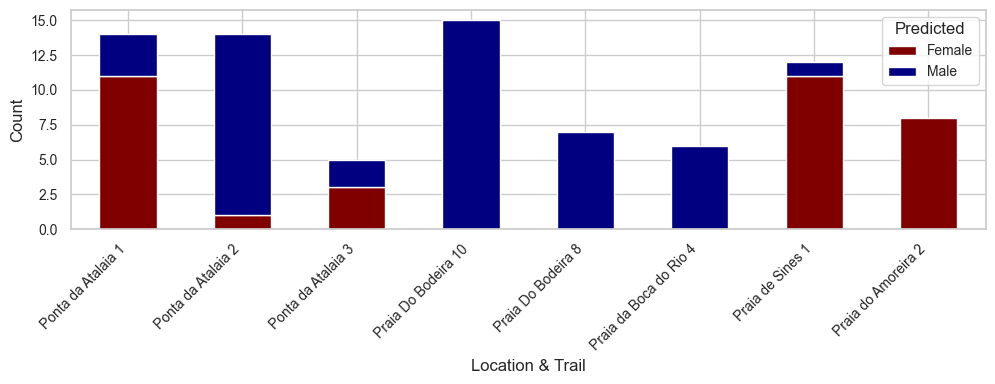

✅ Ergebnisse und Plots gespeichert in: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\eurasian_otter_bayes_search_standard_metrics


In [ ]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all, 
    plot_inference
)
import pandas as pd
import numpy as np
from pathlib import Path
import os, importlib

# ---------------------------------------------------------------------
# Config laden
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# === Konfiguration ===
DEFAULT_SPECIES = "eurasian_otter"
METRIC_KEY = "best_accuracy_test"

# --- Verzeichnis mit den besten Modellen (aus config) ---
BEST_MODEL_DIR = config.RESULTS_DATA_DIR / f"{DEFAULT_SPECIES}_bayes_search_standard_metrics"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# CSV neu erzeugen inkl. Inference mit OOF für Train
df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=METRIC_KEY,          # wichtig!
    prefer_generic=False,
    models_dir=BEST_MODEL_DIR,      # Basis-Verzeichnis
    include_inference=True,
    reuse_csv=False,
    use_cv_train_predictions=True
)

# --- Verteilung Train / Test / Inference prüfen ---
print("Verteilung nach Splits:")
print(df_all["__split__"].value_counts(), "\n")

# --- Kopf zur Kontrolle ---
display(df_all.head())

# --- Mapping Sex-Werte vereinheitlichen ---
sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}
if "pred_sex" in df_all.columns:
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

# --- Inference-Plot erzeugen ---
plot_inference(df_all)

print(f"✅ Ergebnisse und Plots gespeichert in: {BEST_MODEL_DIR}")


Confusion matrix Train und testset

Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
Sex plot directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\Sex_plots


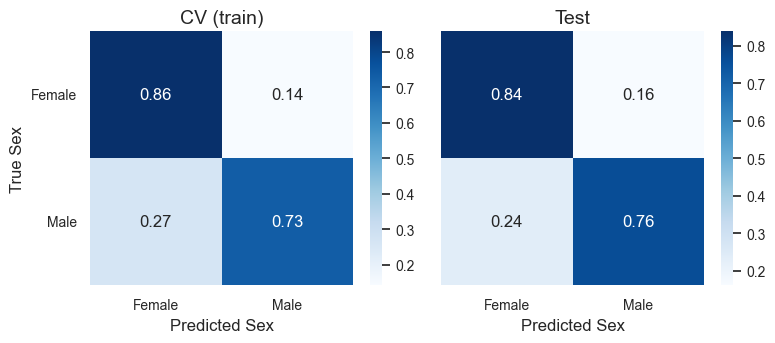

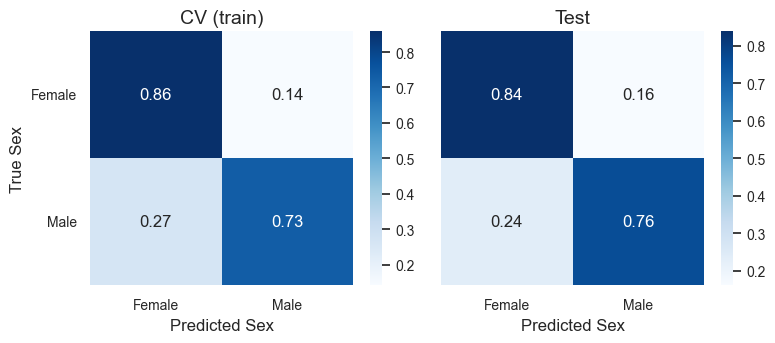

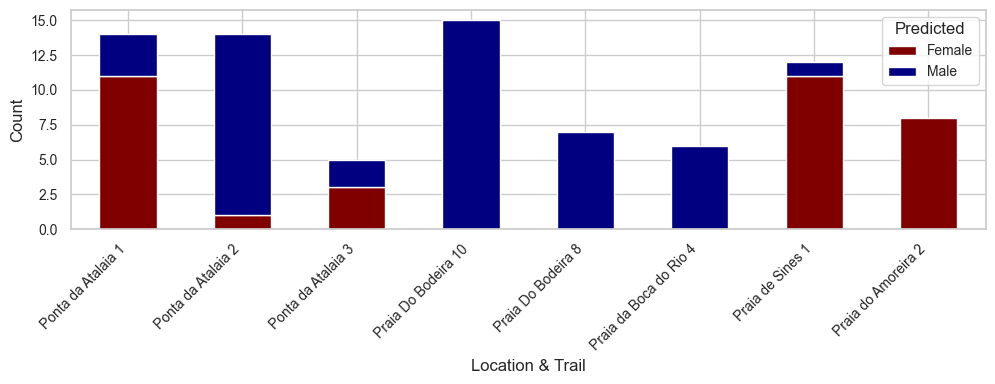

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

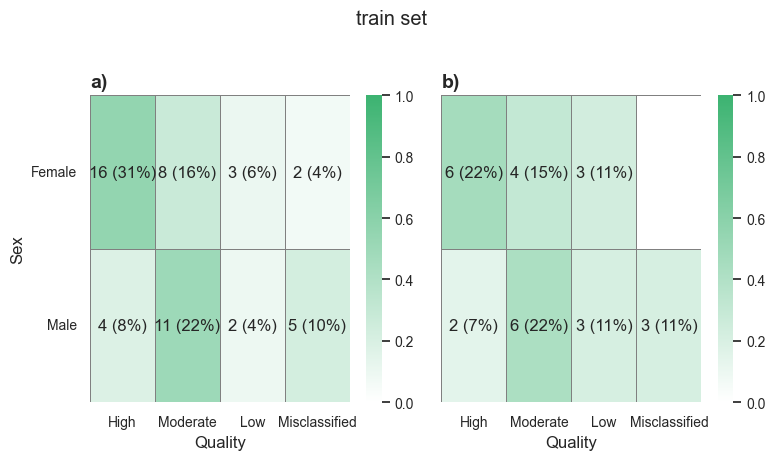

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

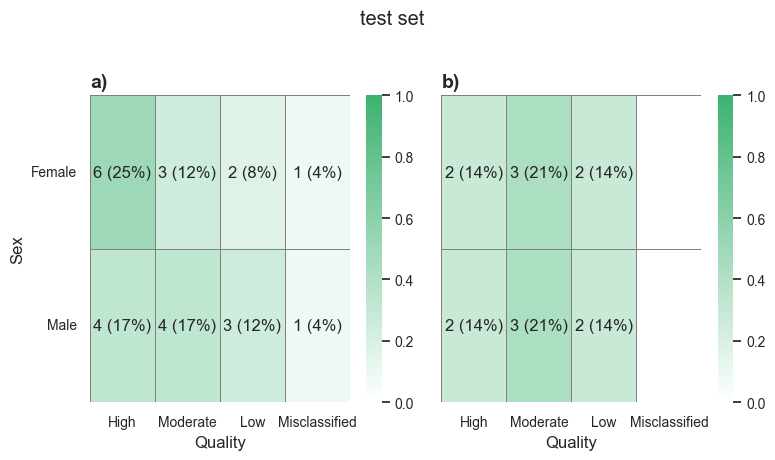

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  f"{int(x)}\n({int(round(x / total * 100))}%)"


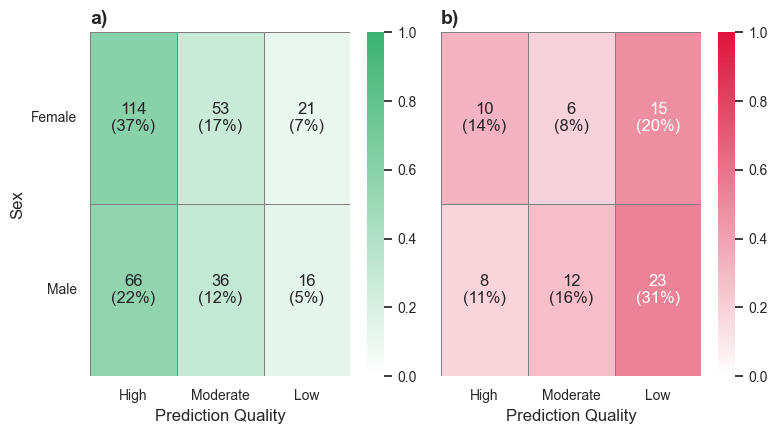

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  f"{int(x)}\n({int(round(x / total * 100))}%)"


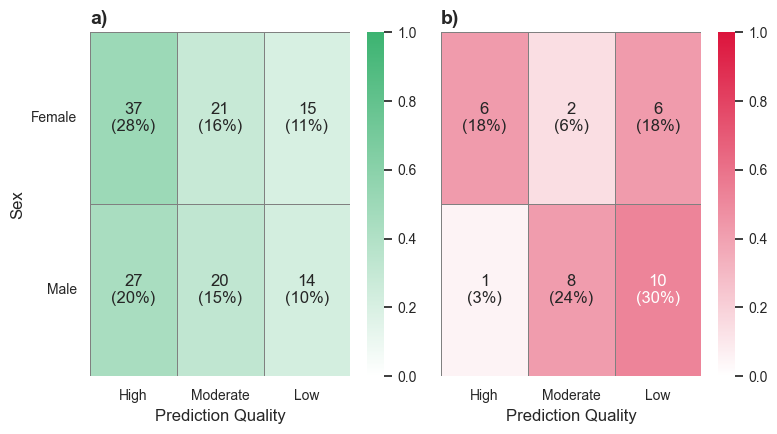

In [ ]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    plot_confusion_and_inference, 
    plot_quality_grouped, 
    plot_quality_heatmaps, 
    plot_individual_probabilities, 
    plot_confusion
)
from FIT_python import config
import importlib
import pandas as pd
from pathlib import Path

# Config neu laden (falls im gleichen Notebook mehrfach geändert wird)
importlib.reload(config)

# --- Basisverzeichnis aus config ---
base_dir = config.EXPERIMENT_ROOT
sex_dir = base_dir / "Sex_plots"
sex_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", base_dir)
print("Sex plot directory:", sex_dir)

# --- Plots erzeugen ---
plot_confusion(df_all)
plot_confusion_and_inference(df_all)
plot_quality_grouped(df_all)   # a) Trail level, b) Individual level
plot_quality_heatmaps(df_all)
# Optional mit Ausgabeordner:
# plot_individual_probabilities(df_all, out_dir=sex_dir)


Baseline Model mit basis FIT parameter

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from FIT_python.pipeline_individual_id.simple_baseline import run_fold_cv, get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Splits aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

# Beispiel: einen Test-Split einer Species laden
test_split = base_dir / "eurasian_otter" / "test.parquet"
if not test_split.exists():
    raise FileNotFoundError(f"Test split not found: {test_split}")

print("Using base_dir:", base_dir)
print("Example test split path:", test_split)

# --- Output-Verzeichnis für Individual ID Ergebnisse ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("Saving results to:", out_base_dir)

results = {}



for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue

    species = sp_dir.name
    print(f"\n##### Starte Pairwise-Analyse für {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    if not train_path.exists() or not test_path.exists():
        print(f"⚠️ Überspringe {species}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)
    feature_cols = get_feature_cols(df_train)

    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1) Cross-Validation mit definierten Folds
    print(f"=== CV für {species} ===")
    if "Fold" not in df_train.columns:
        raise ValueError(f"{species}: Train DataFrame braucht eine 'Fold'-Spalte.")

    cv_out_dir = out_dir / "cv_results"
    cv_out_dir.mkdir(parents=True, exist_ok=True)
    summary_cv = run_fold_cv(
        df_train,
        feature_cols,
        fold_col="Fold",
        out_dir=cv_out_dir,
        reuse_summary=False,
    )
    print(f"✅ CV abgeschlossen für {species}")

    # 2) Test-Paare generieren & Baseline anwenden
    print(f"=== Test-Paare für {species} ===")
    pairs_dir = out_dir / "test_pairs"
    pairs_dir.mkdir(parents=True, exist_ok=True)

    comps_test, _ = generate_pairwise_comparisons_from_df(
        df_test, strategy="select", evaluation=True, subsample=False
    )
    res_df = DistanceBaseline.run(
        train_df=df_train,
        use_sexmodel_prediction=False,
        val_comparisons=comps_test,
        val_df=df_test,
        feature_cols=feature_cols,
        reducers=["lda"],
        selection_method="forward",
        n_components=2,
        n_jobs=-1,
    )
    res_df.to_csv(pairs_dir / f"{species}_pairs.csv", index=False)
    print(f"✅ Test-Paare gespeichert: {pairs_dir / f'{species}_pairs.csv'}")

    # Ergebnisse für später sammeln
    results[species] = {
        "cv_summary": summary_cv,
        "test_pairs": res_df,
    }

print("\n✅ Pairwise-Analyse für alle Spezies abgeschlossen.")


#Basline FIT modelbassiert

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# XGBoost Regularization Grid
xgb_param_grid = {
    "model__reg_alpha":  [0.01, 0.1, 1, 10],
    "model__reg_lambda": [0, 0.1, 1, 10]
}

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n=== Modelle für {species} ===")

    # 1) CV-Paare einlesen
    cv_csv = out_base_dir / species / "cv_results" / "all_folds.csv"
    if not cv_csv.exists():
        print(f"⚠️ CV-Daten fehlen für {species}, überspringe.")
        continue
    df_cv = pd.read_csv(cv_csv)
    df_cv = df_cv[~(df_cv["trail_a_id"].str.strip().eq("unknown") |
                    df_cv["trail_b_id"].str.strip().eq("unknown"))]

    # 2) Test-Paare einlesen
    tp_csv = out_base_dir / species / "test_pairs" / f"{species}_pairs.csv"
    if not tp_csv.exists():
        print(f"⚠️ Test-Paare fehlen für {species}, überspringe.")
        continue
    df_tp = pd.read_csv(tp_csv)
    df_tp = df_tp[~(df_tp["trail_a_id"].str.strip().eq("unknown") |
                    df_tp["trail_b_id"].str.strip().eq("unknown"))]

    # 3) Distanz-Features auswählen
    dist_cols = [c for c in df_cv.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    # 4) NaN rows droppen
    df_cv = df_cv.dropna(subset=dist_cols)
    df_tp = df_tp.dropna(subset=dist_cols)

    # 5) Daten & PredefinedSplit vorbereiten
    X_cv = df_cv[dist_cols].to_numpy()
    y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
    ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

    X_test = df_tp[dist_cols].to_numpy()
    y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

    # ---------------- LDA GridSearch ----------------
    pipe_lda = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(mutual_info_classif, k=5)),
        ("model", LinearDiscriminantAnalysis())
    ])

    # Nur gültige Kombinationen: shrinkage nur mit lsqr, nicht mit svd
    param_grid_lda = [
        {"model__solver": ["svd"], "model__shrinkage": [None]},
        {"model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]}
    ]

    gs_lda = GridSearchCV(
        pipe_lda, param_grid_lda,
        scoring="balanced_accuracy",
        cv=ps, refit=True, n_jobs=-1, verbose=1
    )
    gs_lda.fit(X_cv, y_cv)

    sel_lda = gs_lda.best_estimator_.named_steps["select"]
    top5_lda = np.array(dist_cols)[sel_lda.get_support()].tolist()
    summary_lda = {
        "species": species,
        "cv_bal_acc": balanced_accuracy_score(y_cv, gs_lda.predict(X_cv)),
        "test_bal_acc": balanced_accuracy_score(y_test, gs_lda.predict(X_test)),
        "top5_features": ";".join(top5_lda)
    }
    out_fp_lda = out_base_dir / species / "distance_lda5_summary.csv"
    pd.DataFrame([summary_lda]).to_csv(out_fp_lda, index=False)

    # ---------------- XGBoost GridSearch ----------------
    pipe_xgb = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(mutual_info_classif, k=3)),
        ("model", XGBClassifier(
            eval_metric="logloss",
            booster="gbtree",
            tree_method="hist",
            n_estimators=200
        ))
    ])

    gs_xgb = GridSearchCV(
        pipe_xgb, xgb_param_grid,
        scoring="balanced_accuracy",
        cv=ps, refit=True, n_jobs=-1, verbose=1
    )
    gs_xgb.fit(X_cv, y_cv)

    sel_xgb = gs_xgb.best_estimator_.named_steps["select"]
    top5_xgb = np.array(dist_cols)[sel_xgb.get_support()].tolist()
    summary_xgb = {
        "species": species,
        "cv_bal_acc": balanced_accuracy_score(y_cv, gs_xgb.predict(X_cv)),
        "test_bal_acc": balanced_accuracy_score(y_test, gs_xgb.predict(X_test)),
        "top5_features": ";".join(top5_xgb)
    }
    out_fp_xgb = out_base_dir / species / "distance_xgb3_summary.csv"
    pd.DataFrame([summary_xgb]).to_csv(out_fp_xgb, index=False)
    


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id

=== Modelle für amur_tiger ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Modelle für bengal_tiger ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Modelle für cheetah ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Modelle für eurasian_otter ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Modelle für giant_panda ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 16 

BAseline ERD 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
from sklearn.preprocessing import MinMaxScaler

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# --- Distanz-Spalten definieren ---
base_metrics = ["euclidean"]

cutoff_range = np.arange(0.4, 4.2, 0.1)
benchmark_records = []



for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    out_dir = out_base_dir / species

    # Lade CV-Paare
    cv_csv = out_base_dir / species / "cv_results" / "all_folds.csv"
    if not cv_csv.exists():
        print(f"⚠️ CV-Daten fehlen für {species}, überspringe.")
        continue
    df_cv = pd.read_csv(cv_csv)
    df_cv =  df_cv[ ~( df_cv["trail_a_id"].str.strip().eq("unknown") | df_cv["trail_b_id"].str.strip().eq("unknown"))] #there were some pairs with values not assigned to a trails

    # Finde zusätzlich alle Spalten mit "between"
    between_cols = [col for col in df_cv.columns if "between" in col]

    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    # Lade Test-Paare
    tp_csv = out_dir / "test_pairs" / f"{species}_pairs.csv"
    has_test = tp_csv.exists()
    df_tp    = pd.read_csv(tp_csv) if has_test else None
    df_tp =  df_tp[ ~( df_tp["trail_a_id"].str.strip().eq("unknown") | df_tp["trail_b_id"].str.strip().eq("unknown"))] #there were some pairs with values not assigned to a trails
    
    # --- Hier holen wir uns pipeline als einzelnes Scalar-Label ---
    pipeline = df_cv["pipeline"].iloc[0]

    for dist_col in metrics:
        if dist_col not in df_cv.columns:
            continue

        for prep in ["raw", "minmax"]:
            benchmark_key = {
                "species":       species,
                "pipeline":      pipeline,
                "dist_col":      dist_col,
                "preprocessing": prep,
            }

            # --- 1) CV-Optimierung ---
            recs = []
            for fold_id, fold_df in df_cv.groupby("fold"):
                trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
                D = pd.DataFrame(np.nan, index=trails, columns=trails)
                for a, b, d in zip(
                    fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
                ):
                    D.at[a, b] = D.at[b, a] = d
                np.fill_diagonal(D.values, 0.0)
                D = D.fillna(D.values.max())

                if prep == "minmax":
                    scaler = MinMaxScaler()
                    D[:] = scaler.fit_transform(D)

                true_n = len({*fold_df["ind_a"], *fold_df["ind_b"]})
                for cutoff in cutoff_range:
                    pred_n = cluster_population(D, cutoff)
                    erd    = compute_erd(pred_n, true_n)
                    recs.append({
                        "fold":    fold_id,
                        "cutoff":  cutoff,
                        "erd":     erd,
                        "pred_n":  pred_n,
                        "true_n":  true_n,
                    })

            cut_df = pd.DataFrame(recs)
            mean_erd = cut_df.groupby("cutoff")["erd"].mean().reset_index()
            best     = mean_erd.loc[mean_erd["erd"].idxmin()]
            best_cutoff, mean_erd_cv = float(best["cutoff"]), float(best["erd"])

            # --- 2) Test-ERD berechnen ---
            if has_test:
                trails = sorted({*df_tp["trail_a_id"], *df_tp["trail_b_id"]})
                Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
                for a, b, d in zip(
                    df_tp["trail_a_id"], df_tp["trail_b_id"], df_tp[dist_col]
                ):
                    Dtest.at[a, b] = Dtest.at[b, a] = d
                np.fill_diagonal(Dtest.values, 0.0)
                Dtest = Dtest.fillna(Dtest.values.max())

                if prep == "minmax":
                    scaler = MinMaxScaler()
                    Dtest[:] = scaler.fit_transform(Dtest)

                true_n_t = len({*df_tp["ind_a"], *df_tp["ind_b"]})
                pred_n_t = cluster_population(Dtest, best_cutoff)
                erd_test = compute_erd(pred_n_t, true_n_t)
            else:
                pred_n_t = np.nan
                true_n_t = np.nan
                erd_test  = np.nan

            benchmark_records.append({
                **benchmark_key,
                "cv_cutoff":    best_cutoff,
                "cv_mean_erd":  mean_erd_cv,
                "cv_mean_pred": cut_df.query(f"cutoff=={best_cutoff}")["pred_n"].mean(),
                "cv_mean_true": cut_df.query(f"cutoff=={best_cutoff}")["true_n"].mean(),
                "test_pred_n":  pred_n_t,
                "test_true_n":  true_n_t,
                "test_erd":     erd_test,
            })

# --- Ausgabe ---
benchmark_df  = pd.DataFrame(benchmark_records)
benchmark_csv = out_base_dir / "benchmark_full_distances.csv"
benchmark_df.to_csv(benchmark_csv, index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)


Grid serach mit novelities

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from FIT_python.pipeline_individual_id.simple_baseline import run_fold_cv, get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.soft_config import SOFT_CONFIG

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Splits aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

# --- Output-Verzeichnis für Individual ID Ergebnisse ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)


results = {}
k_range = range(2, 21)
selection_methods = [ "lasso", "random_forest","forward",]
sex_flags = [False, True]

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n##### {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    if not train_path.exists() or not test_path.exists():
        print(f"⚠️ Überspringe {species}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)
    feature_cols = get_feature_cols(df_train)

    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # Sammlung aller Paarvergleiche über CV + Test für dieses Species
    master_pairs = []

    # Sex‑Vorhersagen (OOF für Train, voll trainiertes Modell für Test)
    sex_preds = predict_all(species, reuse_csv=True)

    for fs in selection_methods:
        for k in k_range:
            for use_sex in sex_flags:
                tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"
                run_dir = out_dir / tag
                run_dir.mkdir(parents=True, exist_ok=True)

                # --- 1) CV ---
                cv_dir = run_dir / "cv_results"
                cv_dir.mkdir(parents=True, exist_ok=True)
                summary_cv = run_fold_cv(
                    df_train,
                    feature_cols,
                    sex_predictions=sex_preds,
                    fold_col="Fold",
                    out_dir=cv_dir,
                    selection_method=fs,
                    k_features=k,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    reuse_summary=True,
                )
                print(f"CV fertig: {species} – {tag}")

                # CV-Paare laden und annotieren
                cv_pairs_fp = cv_dir / "all_folds.csv"
                if cv_pairs_fp.exists():
                    cv_pairs = pd.read_csv(cv_pairs_fp)
                    cv_pairs["origin"] = "cv"
                    cv_pairs["tag"] = tag
                    master_pairs.append(cv_pairs)

                # --- 2) Test‑Paare ---
                pairs_dir = run_dir / "test_pairs"
                pairs_dir.mkdir(parents=True, exist_ok=True)

                comps_test, _ = generate_pairwise_comparisons_from_df(
                    df_test, strategy="select", evaluation=True, subsample=False
                )

                SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k
                res_df = DistanceBaseline.run(
                    train_df=df_train,
                    val_comparisons=comps_test,
                    val_df=df_test,
                    feature_cols=feature_cols,
                    selection_method=fs,
                    reducers=["lda"],
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=-1,
                )
                res_df.to_csv(pairs_dir / f"{species}_pairs.csv", index=False)
                print(f"Test‑Paare gespeichert: {pairs_dir / f'{species}_pairs.csv'}")

                # Test-Paare annotieren
                test_pairs = res_df.copy()
                test_pairs["origin"] = "test"
                test_pairs["tag"] = tag
                master_pairs.append(test_pairs)

                results.setdefault(species, []).append({
                    "tag": tag,
                    "cv_summary": summary_cv,
                    "test_pairs": res_df,
                })

    # --- Master-Tabelle für dieses Species ---
    if master_pairs:
        master_df = pd.concat(master_pairs, ignore_index=True)
        master_df.to_csv(out_dir / f"{species}_master_pairs.csv", index=False)

print("\n✅ Analysen für alle Spezies abgeschlossen.")


Benchmark best Individual Classification model for all species 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus Config ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# --- Grid für XGBoost ---
xgb_param_grid = {
    "model__reg_alpha":  [0.01, 0.1, 1, 10],
    "model__reg_lambda": [0, 0.1, 1, 10]
}

# --- Iteration über Spezies ---
for sp_dir in sorted(out_base_dir.iterdir()):
    master_fp = sp_dir / f"{sp_dir.name}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[ ~(df_master["trail_a_id"].str.strip().eq("unknown") |df_master["trail_b_id"].str.strip().eq("unknown")) #there were some pairs with values not assigned to a trails
]
    dist_cols = [c for c in df_master.columns
                 if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

    for tag, df_tag in df_master.groupby("tag"):
        print(f"\n=== {sp_dir.name} – {tag} ===")

        # Split in CV / Test
        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=dist_cols)
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=dist_cols)
        if df_cv.empty or df_tp.empty:
            print("⚠️ Daten unvollständig, überspringe.")
            continue

        X_cv = df_cv[dist_cols].to_numpy()
        y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
        ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

        # --- LDA ---
        pipe_lda = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif, k=5)),
            ("model",  LinearDiscriminantAnalysis())
        ])
        param_grid_lda = {
            "model__shrinkage": [None, 0.1, 0.5, 0.9],
            "model__solver":    ["svd", "lsqr"]
        }
        gs_lda = GridSearchCV(pipe_lda, param_grid_lda,
                              scoring="balanced_accuracy",
                              cv=ps, refit=True, n_jobs=-1, verbose=1)
        gs_lda.fit(X_cv, y_cv)

        X_test = df_tp[dist_cols].to_numpy()
        y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

        y_cv_pred   = gs_lda.predict(X_cv)
        y_test_pred = gs_lda.predict(X_test)

        acc_cv   = balanced_accuracy_score(y_cv, y_cv_pred)
        acc_test = balanced_accuracy_score(y_test, y_test_pred)
        cm_cv    = confusion_matrix(y_cv,   y_cv_pred,   labels=[1, 0])
        cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

        sel_lda = gs_lda.best_estimator_.named_steps["select"]
        top5_lda = np.array(dist_cols)[sel_lda.get_support()].tolist()

        out_dir = sp_dir / tag
        out_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame([{
            "species": sp_dir.name,
            "tag": tag,
            "cv_bal_acc": acc_cv,
            "test_bal_acc": acc_test,
            "cv_true_same_pred_same":   int(cm_cv[0,0]),
            "cv_true_same_pred_diff":   int(cm_cv[0,1]),
            "cv_true_diff_pred_same":   int(cm_cv[1,0]),
            "cv_true_diff_pred_diff":   int(cm_cv[1,1]),
            "test_true_same_pred_same": int(cm_test[0,0]),
            "test_true_same_pred_diff": int(cm_test[0,1]),
            "test_true_diff_pred_same": int(cm_test[1,0]),
            "test_true_diff_pred_diff": int(cm_test[1,1]),
            "top5_features": ";".join(top5_lda)
        }]).to_csv(out_dir / "distance_lda5_summary.csv", index=False)

        # --- XGBoost ---
        pipe_xgb = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif, k=5)),
            ("model",  XGBClassifier(
                use_label_encoder=False,
                eval_metric="logloss",
                booster="gbtree",
                tree_method="hist",
                n_estimators=200
            ))
        ])
        gs_xgb = GridSearchCV(pipe_xgb, xgb_param_grid,
                              scoring="balanced_accuracy",
                              cv=ps, refit=True, n_jobs=-1, verbose=1)
        gs_xgb.fit(X_cv, y_cv)

        y_cv_pred   = gs_xgb.predict(X_cv)
        y_test_pred = gs_xgb.predict(X_test)

        acc_cv   = balanced_accuracy_score(y_cv, y_cv_pred)
        acc_test = balanced_accuracy_score(y_test, y_test_pred)
        cm_cv    = confusion_matrix(y_cv,   y_cv_pred,   labels=[1, 0])
        cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

        sel_xgb = gs_xgb.best_estimator_.named_steps["select"]
        top5_xgb = np.array(dist_cols)[sel_xgb.get_support()].tolist()

        pd.DataFrame([{
            "species": sp_dir.name,
            "tag": tag,
            "cv_bal_acc": acc_cv,
            "test_bal_acc": acc_test,
            "cv_true_same_pred_same":   int(cm_cv[0,0]),
            "cv_true_same_pred_diff":   int(cm_cv[0,1]),
            "cv_true_diff_pred_same":   int(cm_cv[1,0]),
            "cv_true_diff_pred_diff":   int(cm_cv[1,1]),
            "test_true_same_pred_same": int(cm_test[0,0]),
            "test_true_same_pred_diff": int(cm_test[0,1]),
            "test_true_diff_pred_same": int(cm_test[1,0]),
            "test_true_diff_pred_diff": int(cm_test[1,1]),
            "top5_features": ";".join(top5_xgb)
        }]).to_csv(out_dir / "distance_xgb5_summary.csv", index=False)

# --- Benchmark zusammenfassen ---
bench_lda, bench_xgb = [], []
for summary_csv in out_base_dir.rglob("distance_lda5_summary.csv"):
    bench_lda.append(pd.read_csv(summary_csv))
for summary_csv in out_base_dir.rglob("distance_xgb5_summary.csv"):
    bench_xgb.append(pd.read_csv(summary_csv))

benchmark_df = pd.merge(
    pd.concat(bench_lda, ignore_index=True),
    pd.concat(bench_xgb, ignore_index=True),
    on=["species", "tag"],
    suffixes=("_lda", "_xgb")
).sort_values(["species", "tag"])

benchmark_df.to_csv(out_base_dir / "benchmark_distance_combined.csv", index=False)
print("\n=== Gesamt-Benchmark ===")
print(benchmark_df)



=== white_rhino – forward_k20_sex ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [11:42:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== white_rhino – forward_k2_morph ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


...


=== white_rhino – random_forest_k9_sex ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [11:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Gesamt-Benchmark ===
         species  cv_bal_acc_lda  test_bal_acc_lda  \
1     amur_tiger        0.926786          0.927640   
2     amur_tiger        0.940608          0.960452   
3     amur_tiger        0.928108          0.900478   
4     amur_tiger        0.943981          0.908953   
5     amur_tiger        0.924140          0.966102   
..           ...             ...               ...   
916  white_rhino        0.895692          0.838750   
917  white_rhino        0.937927          0.821964   
918  white_rhino        0.909778          0.848929   
919  white_rhino        0.935015          0.832143   
805  white_rhino        0.884021          0.869821   

     cv_true_same_pred_same_lda  cv_true_same_pred_diff_lda  \
1                            37                           3   
2                            38                           2   
3                            37                           3   
4                            37                           3   
5         

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import importlib

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Benchmark einlesen ---
bench_fp = cfg.EXPERIMENT_ROOT / "individual_id" / "benchmark_distance_combined.csv"
if not bench_fp.exists():
    raise FileNotFoundError(f"Benchmark file not found: {bench_fp}")

df = pd.read_csv(bench_fp)

# --- LDA und XGB stacken (inkl. Confusion-Matrix-Zeilen) ---
stacked_records = []
for _, row in df.iterrows():
    for model, suffix in [("lda", "_lda"), ("xgb", "_xgb")]:
        stacked_records.append({
            "species": row["species"],
            "tag": row["tag"],
            "model": model,
            "cv_bal_acc": row[f"cv_bal_acc{suffix}"],
            "test_bal_acc": row[f"test_bal_acc{suffix}"],
            "cv_true_same_pred_same": row[f"cv_true_same_pred_same{suffix}"],
            "cv_true_same_pred_diff": row[f"cv_true_same_pred_diff{suffix}"],
            "cv_true_diff_pred_same": row[f"cv_true_diff_pred_same{suffix}"],
            "cv_true_diff_pred_diff": row[f"cv_true_diff_pred_diff{suffix}"],
            "test_true_same_pred_same": row[f"test_true_same_pred_same{suffix}"],
            "test_true_same_pred_diff": row[f"test_true_same_pred_diff{suffix}"],
            "test_true_diff_pred_same": row[f"test_true_diff_pred_same{suffix}"],
            "test_true_diff_pred_diff": row[f"test_true_diff_pred_diff{suffix}"],
            "top5_features": row[f"top5_features{suffix}"]
        })

stacked_df = pd.DataFrame(stacked_records)

# --- Bestes Modell pro Species nach Test-Accuracy ---
best_df = stacked_df.loc[stacked_df.groupby("species")["test_bal_acc"].idxmax()].reset_index(drop=True)

# --- Speichern ---
out_dir = cfg.EXPERIMENT_ROOT / "individual_id"
best_fp = out_dir / "benchmark_best_models_testonly.csv"
best_df.to_csv(best_fp, index=False)

# --- Top-5 nur für Otter ---
otter_df = stacked_df[stacked_df["species"].str.contains("otter", case=False)]
otter_top5 = otter_df.nlargest(5, "test_bal_acc")

otter_fp = out_dir / "benchmark_otter_top5_testonly.csv"
otter_top5.to_csv(otter_fp, index=False)

# --- Ausgabe in Konsole ---
print("\n=== Best Models by Test Balanced Accuracy ===")
print(best_df)

print("\n=== Top 5 Otter Models by Test Balanced Accuracy ===")
print(otter_top5)



=== Best Models by Test Balanced Accuracy ===
          species                      tag model  cv_bal_acc  test_bal_acc  \
0      amur_tiger             lasso_k3_sex   lda    0.946483      0.985876   
1    bengal_tiger          forward_k12_sex   lda    0.920976      1.000000   
2         cheetah          lasso_k19_morph   lda    0.971052      1.000000   
3  eurasian_otter            lasso_k13_sex   lda    0.881944      0.894872   
4     giant_panda  random_forest_k18_morph   xgb    1.000000      1.000000   
5    lowlandtapir          lasso_k12_morph   xgb    0.963054      1.000000   
6   mountain_lion          forward_k14_sex   xgb    0.987828      1.000000   
7     white_rhino        forward_k20_morph   lda    0.943626      0.945536   

   cv_true_same_pred_same  cv_true_same_pred_diff  cv_true_diff_pred_same  \
0                      35                       2                      16   
1                      61                       8                      16   
2                  

In [ ]:
import pandas as pd
from FIT_python import config as cfg
from pathlib import Path

# --- Verzeichnisse ---
out_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# --- Dateien einlesen ---
baseline_fp = out_dir / "benchmark_best_vs_baseline.csv"
best_fp     = out_dir / "benchmark_best_models_testonly.csv"
otter_fp    = out_dir / "benchmark_otter_top5_testonly.csv"

baseline_df = pd.read_csv(baseline_fp)
best_df     = pd.read_csv(best_fp)

# --- Tags setzen ---
baseline_df["tag"] = "baseline"   # Baseline eindeutig markieren
# best_df behält seinen bestehenden tag

# --- Runden auf 2 Nachkommastellen ---
for df in [baseline_df, best_df]:
    num_cols = df.select_dtypes(include=["float64", "float32", "int64"]).columns
    df[num_cols] = df[num_cols].round(2)

# --- Zusammenführen Baseline + Best ---
combined_df = pd.concat([baseline_df, best_df], ignore_index=True)
combined_df = combined_df.sort_values(["species", "tag"], ascending=[True, True])

# --- Speichern ---
out_fp = out_dir / "benchmark_baseline_plus_best.csv"
combined_df.to_csv(out_fp, index=False)

print("\n=== Baseline + Best Models Combined (gerundet) ===")
print(combined_df)

# --- Otter Top 3 + Baseline ---
if otter_fp.exists():
    otter_best_df = pd.read_csv(otter_fp)
    num_cols = otter_best_df.select_dtypes(include=["float64", "float32", "int64"]).columns
    otter_best_df[num_cols] = otter_best_df[num_cols].round(2)

    # Top 3 Best Models nach Test-Accuracy
    otter_best3 = otter_best_df.sort_values("test_bal_acc", ascending=False).head(3)

    # Baseline aus benchmark_best_vs_baseline.csv (match mit "otter" im Namen)
    otter_baseline = baseline_df[baseline_df["species"].str.contains("otter", case=False, na=False)]
    otter_baseline = otter_baseline.copy()
    otter_baseline["tag"] = "baseline"

    # Reihenfolge: Baseline → Top3
    otter_combined = pd.concat([otter_baseline, otter_best3], ignore_index=True)

    # Runden auch hier sicherstellen
    num_cols = otter_combined.select_dtypes(include=["float64", "float32", "int64"]).columns
    otter_combined[num_cols] = otter_combined[num_cols].round(2)

    # Speichern
    otter_out_fp = out_dir / "benchmark_otter_top3_plus_baseline.csv"
    otter_combined.to_csv(otter_out_fp, index=False)

    print("\n=== Otter Baseline + Top 3 Best Models (gerundet) ===")
    print(otter_combined[["species","cv_bal_acc","test_bal_acc","tag","model","top5_features"]])
else:
    print("\n⚠️ Keine Otter Top5-Datei gefunden:", otter_fp)




=== Baseline + Best Models Combined (gerundet) ===
           species  cv_bal_acc  test_bal_acc  cv_true_same_pred_same  \
0       amur_tiger        0.95          0.92                      37   
8       amur_tiger        0.95          0.99                      35   
1     bengal_tiger        0.93          1.00                      60   
9     bengal_tiger        0.92          1.00                      61   
2          cheetah        0.98          0.95                      98   
10         cheetah        0.97          1.00                      99   
3   eurasian_otter        0.86          0.85                      22   
11  eurasian_otter        0.88          0.89                      35   
4      giant_panda        0.99          0.99                      45   
12     giant_panda        1.00          1.00                      46   
5     lowlandtapir        1.00          0.88                      29   
13    lowlandtapir        0.96          1.00                      27   
6    mountai

Benchmark improvements erd pipliens

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

# Distanz-Metriken
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

cutoff_range = np.arange(0.4, 4.2, 0.1)


def evaluate_clusters(D, true_labels, cutoff):
    """Clustern und Cluster-Metriken berechnen."""
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v


def process_combination(species, tag, dist_col, prep, df_cv, df_test):
    bench_key = {
        "species": species,
        "tag": tag,
        "dist_col": dist_col,
        "preprocessing": prep,
    }

    try:
        # ---------------- CV: Cutoff-Optimierung ----------------
        recs = []
        for fold_id, fold_df in df_cv.groupby("fold"):
            trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
            D = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
            ):
                D.at[a, b] = D.at[b, a] = d
            np.fill_diagonal(D.values, 0.0)
            D = D.fillna(D.values.max())

            if prep == "minmax":
                D[:] = MinMaxScaler().fit_transform(D)

            # Wahre Labels für Trails
            label_map = {}
            label_map.update(fold_df.set_index("trail_a_id")["ind_a"].to_dict())
            label_map.update(fold_df.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels = [str(label_map[t]) for t in trails]
            true_n = len(np.unique(true_labels))

            for cutoff in cutoff_range:
                cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
                pred_n = len(np.unique(cluster_labels))
                erd = compute_erd(pred_n, true_n)

                score = alpha * (1 - erd) + (1 - alpha) * v  # Gewichtung hier!

                recs.append({
                    "species": species,
                    "tag": tag,
                    "dist_col": dist_col,
                    "preprocessing": prep,
                    "fold": fold_id,
                    "cutoff": cutoff,
                    "erd": erd,
                    "pred_n": pred_n,
                    "true_n": true_n,
                    "homogeneity": h,
                    "completeness": c,
                    "v_measure": v,
                    "score": score
                })


        cut_df = pd.DataFrame(recs)
        mean_scores = cut_df.groupby("cutoff")[["erd","homogeneity","completeness","v_measure"]].mean().reset_index()
        best = mean_scores.loc[mean_scores["erd"].idxmin()]
        best_cutoff = float(best["cutoff"])
        mean_erd_cv = float(best["erd"])
        mean_h_cv   = float(best["homogeneity"])
        mean_c_cv   = float(best["completeness"])
        mean_v_cv   = float(best["v_measure"])

        # ---------------- Test-Set ----------------
        if not df_test.empty:
            trails = sorted({*df_test["trail_a_id"], *df_test["trail_b_id"]})
            Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                df_test["trail_a_id"], df_test["trail_b_id"], df_test[dist_col]
            ):
                Dtest.at[a, b] = Dtest.at[b, a] = d
            np.fill_diagonal(Dtest.values, 0.0)
            Dtest = Dtest.fillna(Dtest.values.max())

            if prep == "minmax":
                Dtest[:] = MinMaxScaler().fit_transform(Dtest)

            label_map_test = {}
            label_map_test.update(df_test.set_index("trail_a_id")["ind_a"].to_dict())
            label_map_test.update(df_test.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels_test = [str(label_map_test[t]) for t in trails]
            true_n_t = len(np.unique(true_labels_test))

            cluster_labels, h_t, c_t, v_t = evaluate_clusters(Dtest, true_labels_test, best_cutoff)
            pred_n_t = len(np.unique(cluster_labels))
            erd_test = compute_erd(pred_n_t, true_n_t)
        else:
            pred_n_t = true_n_t = erd_test = h_t = c_t = v_t = np.nan

        return {
            **bench_key,
            "cv_cutoff": best_cutoff,
            "cv_mean_erd": mean_erd_cv,
            "cv_mean_homogeneity": mean_h_cv,
            "cv_mean_completeness": mean_c_cv,
            "cv_mean_v_measure": mean_v_cv,
            "test_pred_n": pred_n_t,
            "test_true_n": true_n_t,
            "test_erd": erd_test,
            "test_homogeneity": h_t,
            "test_completeness": c_t,
            "test_v_measure": v_t,
            "status": "ok",
            "cut_df": cut_df
        }

    except Exception as e:
        return {**bench_key, "status": f"skipped: {e}"}


all_tasks = []
# Optionaler Tag-Filter:
# wanted_tags = ["forward_k16_morph", "lasso_k13_sex", "lasso_k16_sex", "lasso_k19_sex"]

for sp_dir in sorted(out_base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name

    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[
        ~(df_master["trail_a_id"].str.strip().eq("unknown") |
          df_master["trail_b_id"].str.strip().eq("unknown"))
    ]

    between_cols = [c for c in df_master.columns if "between" in c]
    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    for tag, df_tag in df_master.groupby("tag"):
        # Filter nur aktivieren, wenn wanted_tags gesetzt ist
        # if tag not in wanted_tags:
        #     continue

        df_cv = df_tag[df_tag["origin"] == "cv"]
        df_test = df_tag[df_tag["origin"] == "test"]

        for dist_col in metrics:
            if dist_col not in df_tag.columns:
                continue
            for prep in ["raw", "minmax"]:
                all_tasks.append((species, tag, dist_col, prep, df_cv, df_test))

print(f"Gesammelte Tasks: {len(all_tasks)}")


print(f"Starte {len(all_tasks)} Kombinationen …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# Speichern
records, cutoff_records = [], []
for res in results:
    if res["status"] == "ok":
        cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_base_dir / "benchmark_full_distances_with_metrics.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_base_dir / "benchmark_cutoff_curves_with_metrics.csv", index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)
display(cutoff_df)

Starte 144 Kombinationen …


100%|██████████| 144/144 [00:03<00:00, 38.29it/s]


=== Benchmark Summary ===


,species,tag,dist_col,preprocessing,cv_cutoff,cv_mean_erd,cv_mean_homogeneity,cv_mean_completeness,cv_mean_v_measure,test_pred_n,test_true_n,test_erd,test_homogeneity,test_completeness,test_v_measure,status
0,eurasian_otter,forward_k16_morph,dist_euclidean,raw,2.9,0.153333,0.874981,0.903005,0.885487,12,14,0.142857,0.890348,0.928069,0.908817,ok
1,eurasian_otter,forward_k16_morph,dist_euclidean,minmax,0.7,0.113333,0.890179,0.928278,0.907118,11,14,0.214286,0.890348,0.962693,0.925108,ok
2,eurasian_otter,forward_k16_morph,dist_manhattan,raw,3.8,0.080000,0.832612,0.857834,0.843762,11,14,0.214286,0.855845,0.925385,0.889257,ok
3,eurasian_otter,forward_k16_morph,dist_manhattan,minmax,0.7,0.120000,0.900892,0.943282,0.916204,12,14,0.142857,0.880894,0.927353,0.903526,ok
4,eurasian_otter,forward_k16_morph,dist_cosine,raw,0.7,0.186667,0.926814,0.892567,0.905533,12,14,0.142857,0.865299,0.901958,0.883249,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,eurasian_otter,lasso_k19_sex,median_canberra_between,minmax,0.8,0.220000,0.693398,0.830253,0.752798,8,14,0.428571,0.694844,0.880775,0.776839,ok
140,eurasian_otter,lasso_k19_sex,mean_braycurtis_between,raw,0.9,0.186667,0.894556,0.933561,0.906324,12,14,0.142857,0.859159,0.901327,0.879738,ok
141,eurasian_otter,lasso_k19_sex,mean_braycurtis_between,minmax,0.5,0.146667,0.889252,0.894017,0.888890,10,14,0.285714,0.805746,0.921112,0.859575,ok
142,eurasian_otter,lasso_k19_sex,median_braycurtis_between,raw,0.9,0.153333,0.846465,0.946497,0.889849,11,14,0.214286,0.865299,0.926140,0.894687,ok


,species,tag,dist_col,preprocessing,fold,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score
0,eurasian_otter,forward_k16_morph,dist_euclidean,raw,0.0,0.4,0.5,9,6,1.0,0.78969,0.882488,0.691244
1,eurasian_otter,forward_k16_morph,dist_euclidean,raw,0.0,0.5,0.5,9,6,1.0,0.78969,0.882488,0.691244
2,eurasian_otter,forward_k16_morph,dist_euclidean,raw,0.0,0.6,0.5,9,6,1.0,0.78969,0.882488,0.691244
3,eurasian_otter,forward_k16_morph,dist_euclidean,raw,0.0,0.7,0.5,9,6,1.0,0.78969,0.882488,0.691244
4,eurasian_otter,forward_k16_morph,dist_euclidean,raw,0.0,0.8,0.5,9,6,1.0,0.78969,0.882488,0.691244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27355,eurasian_otter,lasso_k19_sex,median_braycurtis_between,minmax,4.0,3.7,0.8,1,5,0.0,1.00000,0.000000,0.100000
27356,eurasian_otter,lasso_k19_sex,median_braycurtis_between,minmax,4.0,3.8,0.8,1,5,0.0,1.00000,0.000000,0.100000
27357,eurasian_otter,lasso_k19_sex,median_braycurtis_between,minmax,4.0,3.9,0.8,1,5,0.0,1.00000,0.000000,0.100000
27358,eurasian_otter,lasso_k19_sex,median_braycurtis_between,minmax,4.0,4.0,0.8,1,5,0.0,1.00000,0.000000,0.100000


In [ ]:
import pandas as pd
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Species + Tag bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","cv_best_score"], ascending=[True, True, False])
    .groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")


=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===


,species,tag,cutoff,erd,homogeneity,completeness,v_measure,cv_best_score
0,eurasian_otter,forward_k16_morph,0.6,0.073333,0.912071,0.931974,0.921066,0.923866
1,eurasian_otter,forward_k16_morph,3.9,0.073333,0.876344,0.893926,0.883769,0.905218
2,eurasian_otter,forward_k16_morph,4.0,0.073333,0.876344,0.893926,0.883769,0.905218
3,eurasian_otter,forward_k16_morph,0.7,0.113333,0.921379,0.919069,0.917921,0.902294
4,eurasian_otter,forward_k16_morph,0.9,0.073333,0.868238,0.879213,0.871246,0.898956
...,...,...,...,...,...,...,...,...
5467,eurasian_otter,lasso_k19_sex,4.1,0.813333,0.000000,1.000000,0.000000,0.093333
5468,eurasian_otter,lasso_k19_sex,4.1,0.813333,0.000000,1.000000,0.000000,0.093333
5469,eurasian_otter,lasso_k19_sex,4.1,0.813333,0.000000,1.000000,0.000000,0.093333
5470,eurasian_otter,lasso_k19_sex,4.1,0.813333,0.000000,1.000000,0.000000,0.093333



✅ Ergebnisse gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\best_cutoffs_combined_score_mean.csv


=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===


,species,tag,dist_col,preprocessing,cutoff,erd,homogeneity,completeness,v_measure,cv_best_score
0,eurasian_otter,forward_k16_morph,dist_braycurtis,minmax,0.5,0.220000,0.941738,0.843107,0.888346,0.834173
1,eurasian_otter,forward_k16_morph,dist_braycurtis,raw,0.9,0.146667,0.856574,0.919200,0.881197,0.867265
2,eurasian_otter,forward_k16_morph,dist_canberra,minmax,0.7,0.186667,0.694174,0.804513,0.742672,0.778003
3,eurasian_otter,forward_k16_morph,dist_canberra,raw,1.2,0.220000,0.745454,0.815290,0.773399,0.776699
4,eurasian_otter,forward_k16_morph,dist_chebyshev,minmax,0.6,0.073333,0.912071,0.931974,0.921066,0.923866
...,...,...,...,...,...,...,...,...,...,...
139,eurasian_otter,lasso_k19_sex,median_cosine_between,raw,0.7,0.153333,0.901258,0.915807,0.901594,0.874130
140,eurasian_otter,lasso_k19_sex,median_euclidean_between,minmax,0.6,0.120000,0.982245,0.924805,0.950988,0.915494
141,eurasian_otter,lasso_k19_sex,median_euclidean_between,raw,3.6,0.040000,0.908597,0.934154,0.920504,0.940252
142,eurasian_otter,lasso_k19_sex,median_manhattan_between,minmax,0.7,0.153333,0.914784,0.981630,0.941528,0.894097



✅ Ergebnisse gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\best_cutoffs_combined_score_mean.csv

📊 Beste Pipeline: eurasian_otter, lasso_k16_sex, median_euclidean_between, raw


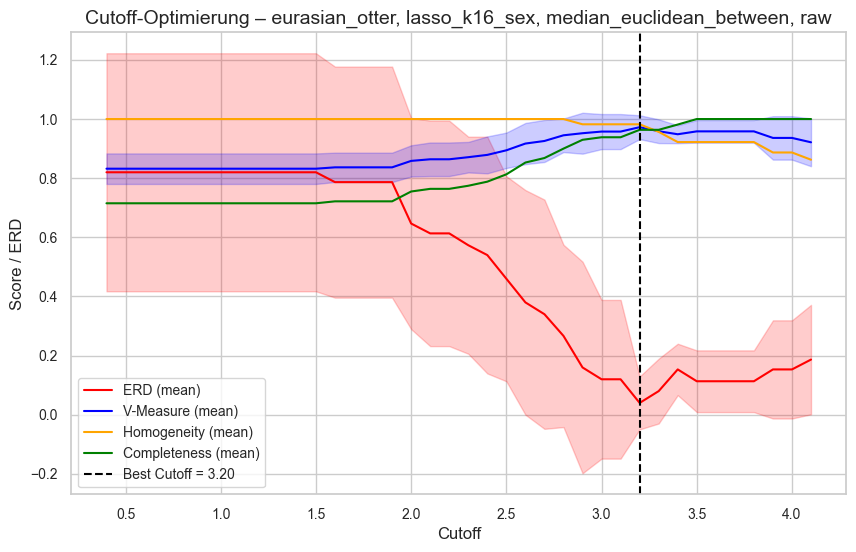

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","dist_col","preprocessing","cutoff"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Pipeline bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","dist_col","preprocessing","cv_best_score"],
                            ascending=[True, True, True, True, False])
    .groupby(["species","tag","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","dist_col","preprocessing","cutoff",
    "erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")

# --- Plot für die beste Pipeline ---
# Beste Pipeline wählen
best_pipeline = best_cutoffs.sort_values("cv_best_score", ascending=False).iloc[0]
species = best_pipeline["species"]
tag = best_pipeline["tag"]
dist_col = best_pipeline["dist_col"]
prep = best_pipeline["preprocessing"]

print(f"\n📊 Beste Pipeline: {species}, {tag}, {dist_col}, {prep}")

df_plot = cutoff_df.query(
    "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
)

mean_scores_plot = (
    df_plot.groupby("cutoff")
    .agg({
        "erd": ["mean","std"],
        "homogeneity": ["mean","std"],
        "completeness": ["mean","std"],
        "v_measure": ["mean","std"],
        "cv_best_score": ["mean","std"]
    })
    .reset_index()
)
mean_scores_plot.columns = ["cutoff","erd_mean","erd_std","hom_mean","hom_std",
                            "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"]

# Plotten
plt.figure(figsize=(10,6))
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["erd_mean"], color="red", label="ERD (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"],
                 mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"],
                 color="red", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["v_mean"], color="blue", label="V-Measure (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
                 mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
                 color="blue", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["hom_mean"], color="orange", label="Homogeneity (mean)")
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["comp_mean"], color="green", label="Completeness (mean)")

best_cutoff = best_pipeline["cutoff"]
plt.axvline(best_cutoff, color="black", linestyle="--", 
            label=f"Best Cutoff = {best_cutoff:.2f}")

plt.xlabel("Cutoff")
plt.ylabel("Score / ERD")
plt.title(f"Cutoff-Optimierung – {species}, {tag}, {dist_col}, {prep}")
plt.legend()
plt.grid(True)
plt.show()


#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

=== Fold 0 ===


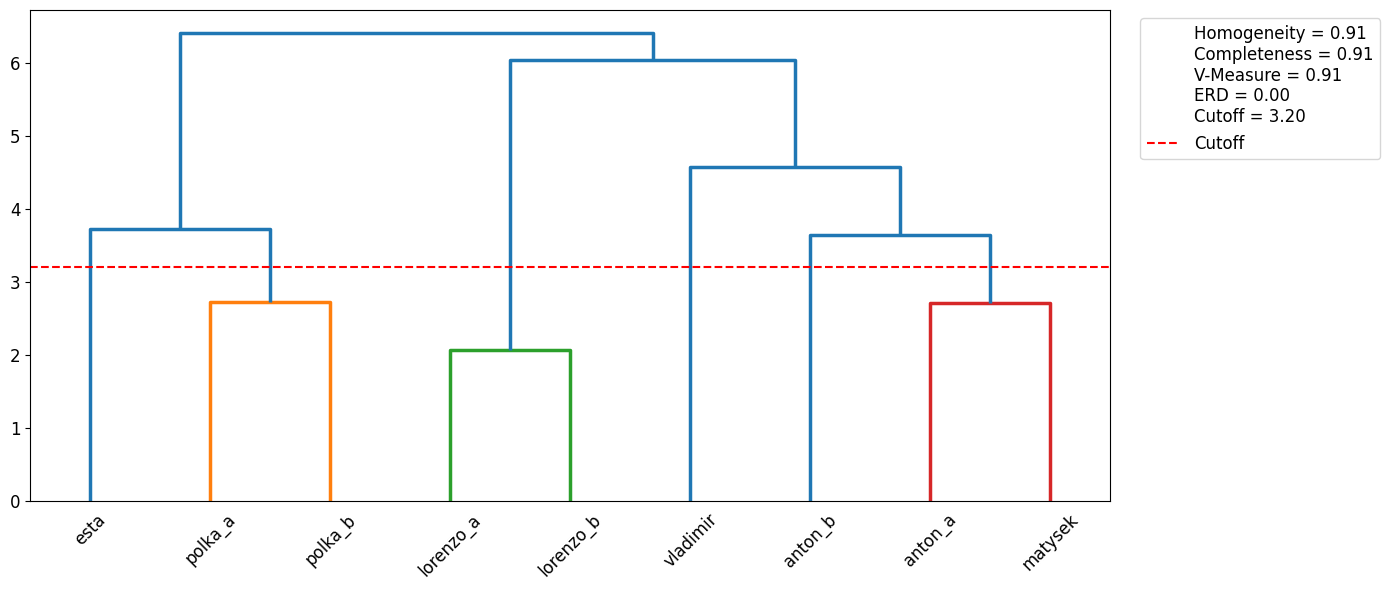

=== Fold 1 ===


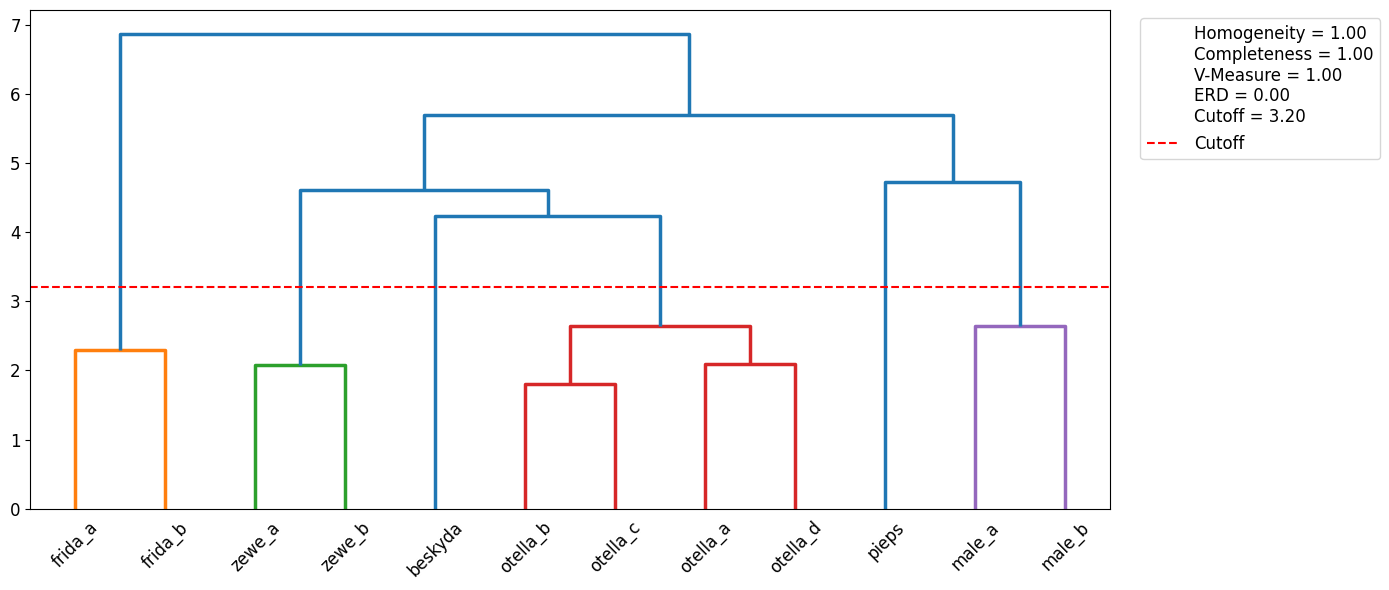

=== Fold 2 ===


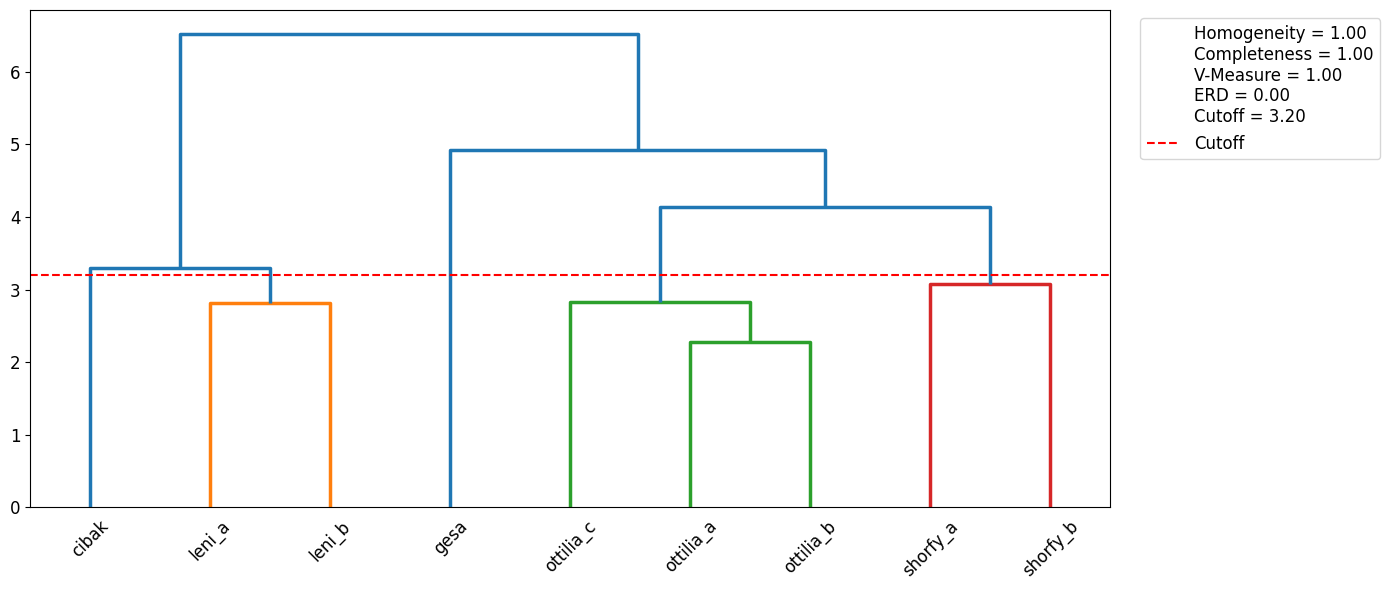

=== Fold 3 ===


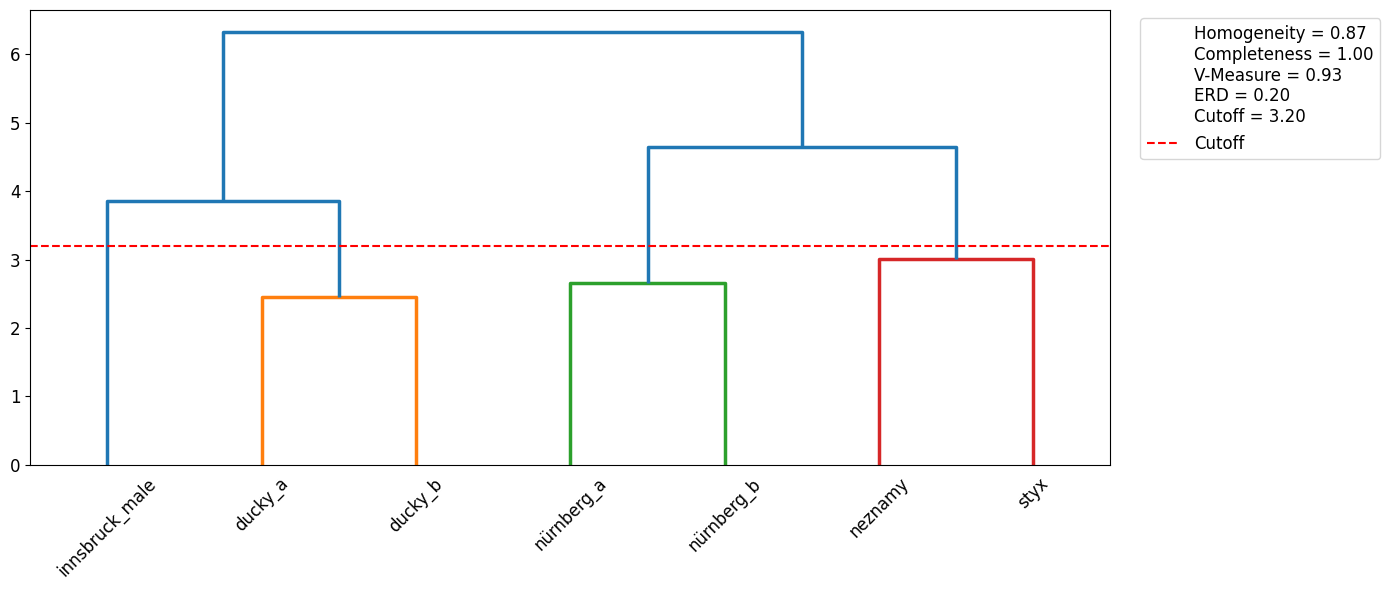

=== Fold 4 ===


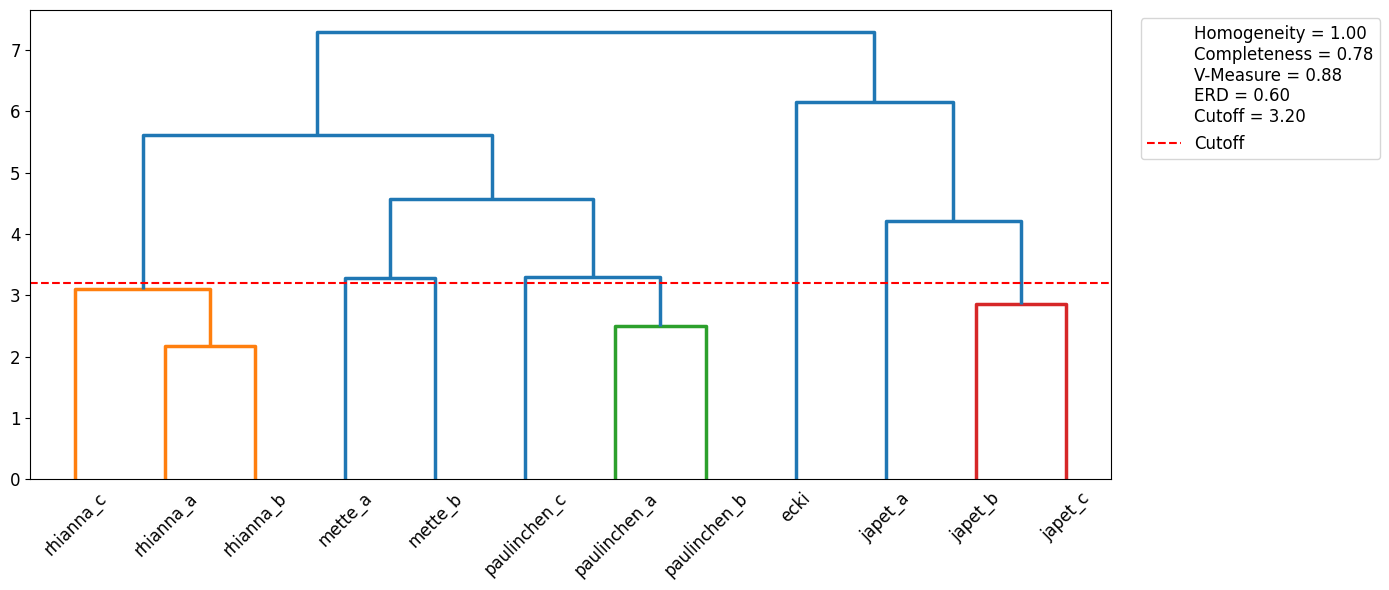

=== Testset ===


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_label = type_of_target(labels_true)
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(labels_pred)
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_label = type_of_target(labels_true)
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation

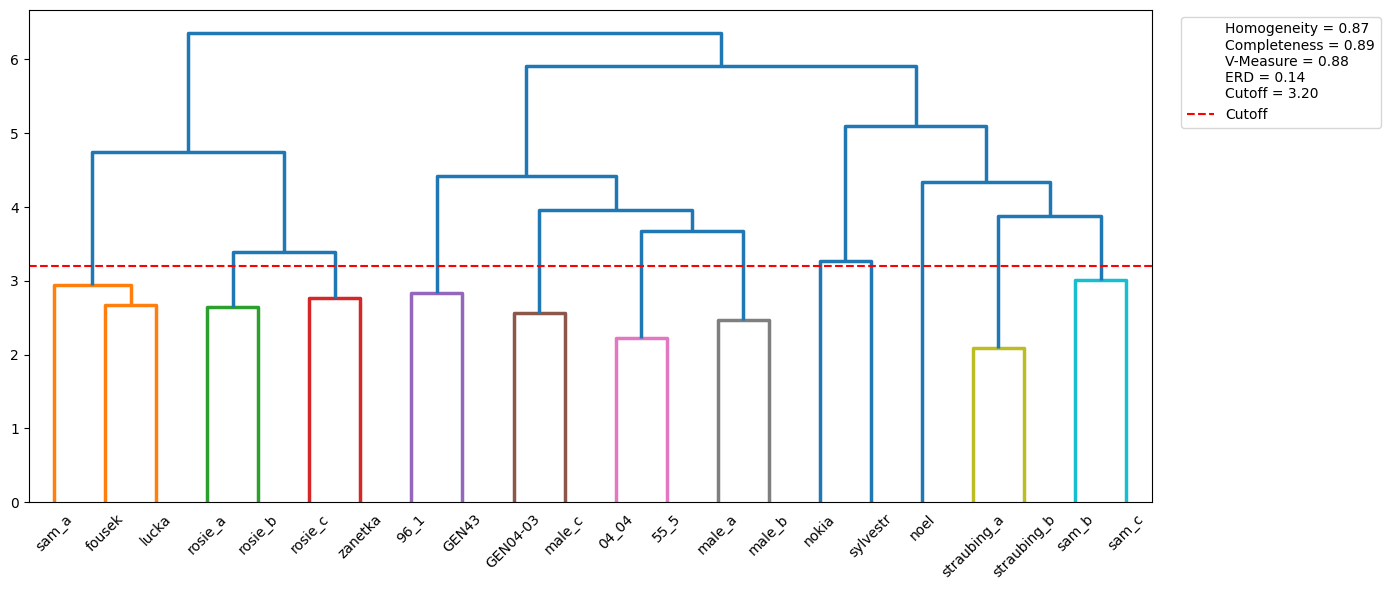

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import matplotlib as mpl
from FIT_python import config as cfg
import re


# --- Master-Pairs laden ---
otter_master_fp = cfg.EXPERIMENT_ROOT / "individual_id" / "eurasian_otter" / "eurasian_otter_master_pairs.csv"
df_master = pd.read_csv(otter_master_fp)

# Filter nach Pipeline + ohne "unknown"-Trails
df_filtered = (
    df_master[df_master["pipeline"] == "lasso_no_out_standard_k16_lda_nc2_sex_on"]
    .query("trail_a_id != 'unknown' and trail_b_id != 'unknown'")
    .copy()
)
dist_col = "mean_euclidean_between"
df = df_filtered

def plot_dendrogram(df_sub, cutoff=3.2, scaled=False):
    from matplotlib.lines import Line2D

    # Trails sammeln
    trails = sorted({*df_sub["trail_a_id"], *df_sub["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)

    for a, b, d in zip(df_sub["trail_a_id"], df_sub["trail_b_id"], df_sub[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    # Optionales Scaling
    if scaled:
        D_values = MinMaxScaler().fit_transform(D.values)
    else:
        D_values = D.values

    # Clustering
    condensed = squareform(D_values, checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    # Wahre Labels bauen
    trail_to_true = {**dict(zip(df_sub["trail_a_id"], df_sub["ind_a"])),
                     **dict(zip(df_sub["trail_b_id"], df_sub["ind_b"]))}
    true_labels = [trail_to_true[t] for t in trails]

    # Wörter definieren, die entfernt werden sollen
 
    # Wörter definieren, die entfernt werden sollen
    remove_words = [
        "hankensbüttel", "female",  "pforzheim","naturoparc",
        "naturopark", "nuturopark", "salzburg", "wiesbaden", "salzburg"
    ] # "straubing", "male"

    def clean_label(label):
        # --- Schritt 1: Wörter entfernen ---
        parts = label.split("_")
        cleaned_parts = [p for p in parts if p.lower() not in remove_words]
        label_clean = "_".join(cleaned_parts)

        # --- Schritt 2: Nur GEN + ID behalten ---
        gen_match = re.search(r"gen(?:etik_probe_)?(\d+(?:[_-]\d+)*)", label_clean.lower())
        if gen_match:
            gen_id = gen_match.group(1).replace("_", "-").upper()
            return f"GEN{gen_id}"

        # --- Falls kein GEN: letzten zwei Parts ---
        short = "_".join(label_clean.split("_")[-2:])
        return short if short else label_clean

    # Anwendung
    short_labels = [clean_label(t) for t in trails]


    # Plot erstellen
    plt.figure(figsize=(14, 6))
    dendro = dendrogram(
        link,
        labels=short_labels,
        leaf_rotation=45,
        color_threshold=cutoff,
    )

    # Achsen-Formatierung
    ax = plt.gca()
    tick_size = ax.xaxis.get_ticklabels()[0].get_size()
    plt.setp(ax.get_xticklabels(), color="black", fontsize=tick_size, rotation=45)
    plt.setp(ax.get_yticklabels(), fontsize=tick_size)
    plt.setp(ax.collections, linewidth=2.5)

    # Cutoff-Linie
    cutoff_line = plt.axhline(y=cutoff, color="red", linestyle="--", label="Cutoff")

    # Cluster-Metriken berechnen
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    erd = abs(len(set(cluster_labels)) - len(set(true_labels))) / len(set(true_labels))

    metrics_text = (
        f"Homogeneity = {h:.2f}\n"
        f"Completeness = {c:.2f}\n"
        f"V-Measure = {v:.2f}\n"
        f"ERD = {erd:.2f}\n"
        f"Cutoff = {cutoff:.2f}"
    )

    dummy = Line2D([], [], color="none")
    plt.legend(
        [dummy, cutoff_line],
        [metrics_text, "Cutoff"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=tick_size,
        frameon=True,
        fancybox=True,
    )

    plt.tight_layout()
    plt.show()



# --- CV Folds ---
for fold in sorted(df["fold"].dropna().unique()):
    df_fold = df[(df["origin"] == "cv") & (df["fold"] == fold)].copy()
    print(f"=== Fold {int(fold)} ===")
    plot_dendrogram(df_fold, cutoff=3.2, scaled=False)

# --- Testset ---
df_test = df[df["origin"] == "test"].copy()
if not df_test.empty:
    print("=== Testset ===")
    plot_dendrogram(df_test, cutoff=3.2, scaled=False)


In [ ]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.soft_config import SOFT_CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 50                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = True                          # True → Sexmodell einbinden, False → ohne

SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

# -----------------------------------------------------------
# 3) Sequential Holdout auf dem Trainingssatz
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=10,                      # Anzahl der Holdout-Iterationen
    val_sizes=[2, 4, 6, 8],             # Größe der Validierungsgruppen
    k_features=k,
    use_sexmodel_prediction=use_sex,
    sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_train"
)

# -----------------------------------------------------------
# 4) Sequential Holdout im "Validation Mode" auf dem Testsatz
#    (hier wird der Testsatz als eine einzige Validierungsgruppe benutzt)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_test"
)

display(train_summary)
display(test_summary)



=== Sequential Holdout für Modell: baseline ===
→ Params: {'selection_method': 'forward', 'k_features': 16, 'use_sex': False}


TypeError: run() got an unexpected keyword argument 'df_train'

Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set